In [ ]:
from sklearn.datasets import fetch_lfw_people

lfw = fetch_lfw_people(min_faces_per_person=20, resize=0.4)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [ ]:
lfw = fetch_lfw_people(
    min_faces_per_person=20,
    resize=0.5,
    color=True
)

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [ ]:
X = lfw.images
y = lfw.target

print("Image Shape :", X.shape)
print("Number of Classes :", len(lfw.target_names))
print("Target Shape :", y.shape)

Image Shape : (3023, 62, 47, 3)
Number of Classes : 62
Target Shape : (3023,)


In [ ]:
print("Classes:\n")

print(lfw.target_names)

Classes:

['Alejandro Toledo' 'Alvaro Uribe' 'Amelie Mauresmo' 'Andre Agassi'
 'Angelina Jolie' 'Ariel Sharon' 'Arnold Schwarzenegger'
 'Atal Bihari Vajpayee' 'Bill Clinton' 'Carlos Menem' 'Colin Powell'
 'David Beckham' 'Donald Rumsfeld' 'George Robertson' 'George W Bush'
 'Gerhard Schroeder' 'Gloria Macapagal Arroyo' 'Gray Davis'
 'Guillermo Coria' 'Hamid Karzai' 'Hans Blix' 'Hugo Chavez' 'Igor Ivanov'
 'Jack Straw' 'Jacques Chirac' 'Jean Chretien' 'Jennifer Aniston'
 'Jennifer Capriati' 'Jennifer Lopez' 'Jeremy Greenstock' 'Jiang Zemin'
 'John Ashcroft' 'John Negroponte' 'Jose Maria Aznar'
 'Juan Carlos Ferrero' 'Junichiro Koizumi' 'Kofi Annan' 'Laura Bush'
 'Lindsay Davenport' 'Lleyton Hewitt' 'Luiz Inacio Lula da Silva'
 'Mahmoud Abbas' 'Megawati Sukarnoputri' 'Michael Bloomberg' 'Naomi Watts'
 'Nestor Kirchner' 'Paul Bremer' 'Pete Sampras' 'Recep Tayyip Erdogan'
 'Ricardo Lagos' 'Roh Moo-hyun' 'Rudolph Giuliani' 'Saddam Hussein'
 'Serena Williams' 'Silvio Berlusconi' 'Tiger Woods

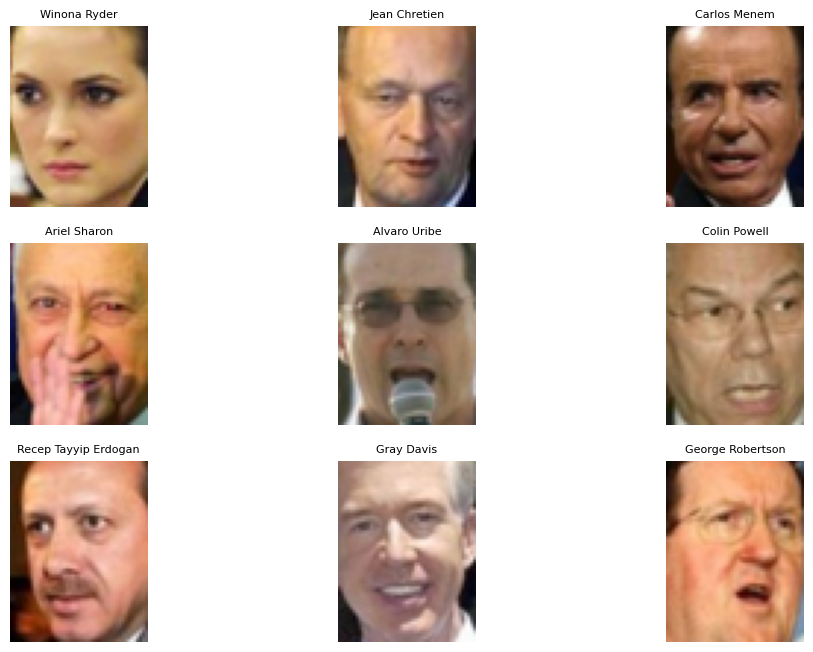

In [ ]:
plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X[i])

    plt.title(lfw.target_names[y[i]], fontsize=8)

    plt.axis("off")

plt.show()

In [ ]:
X = X.astype("float32") / 255.0

print("Images Normalized Successfully!")

Images Normalized Successfully!


In [ ]:
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

y_encoded = to_categorical(y_encoded)

print("Labels Encoded Successfully!")

Labels Encoded Successfully!


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y_encoded,

    test_size=0.20,

    random_state=42
)

print("Training Images :", X_train.shape)

print("Testing Images :", X_test.shape)

Training Images : (2418, 62, 47, 3)
Testing Images : (605, 62, 47, 3)


In [ ]:
print("Training Labels :", y_train.shape)

print("Testing Labels :", y_test.shape)

Training Labels : (2418, 62)
Testing Labels : (605, 62)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Build CNN Model
model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(62, 47, 3)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(len(lfw.target_names), activation='softmax')

])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 60, 45, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 20, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8960)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,147,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 62)             │         7,998 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,174,398 (4.48 MB)

 Trainable params: 1,174,398 (4.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [ ]:
history = model.fit(

    X_train,
    y_train,

    validation_data=(X_test, y_test),

    epochs=30,

    batch_size=32

)

Epoch 1/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 10s 137ms/step - accuracy: 0.1791 - loss: 3.6801 - val_accuracy: 0.1603 - val_loss: 3.7140
Epoch 2/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 21s 140ms/step - accuracy: 0.1791 - loss: 3.6749 - val_accuracy: 0.1603 - val_loss: 3.7178
Epoch 3/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 21s 153ms/step - accuracy: 0.1791 - loss: 3.6792 - val_accuracy: 0.1603 - val_loss: 3.7122
Epoch 4/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step - accuracy: 0.1791 - loss: 3.6716 - val_accuracy: 0.1603 - val_loss: 3.7167
Epoch 5/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 11s 133ms/step - accuracy: 0.1791 - loss: 3.6677 - val_accuracy: 0.1603 - val_loss: 3.7110
Epoch 6/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 11s 142ms/step - accuracy: 0.1791 - loss: 3.6691 - val_accuracy: 0.1603 - val_loss: 3.7100
Epoch 7/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 11s 139ms/step - accuracy: 0.1791 - loss: 3.6547 - val_accuracy: 0.1603 - val_loss: 3.6815
Epoch 8/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 9s 113ms/step - accuracy: 0.1791 - loss: 3.6310 - val_accura

In [21]:
predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = np.argmax(y_test, axis=1)

print("Prediction Completed Successfully!")

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step
Prediction Completed Successfully!


In [22]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.4678 - loss: 2.2558
Test Accuracy: 0.4677686095237732


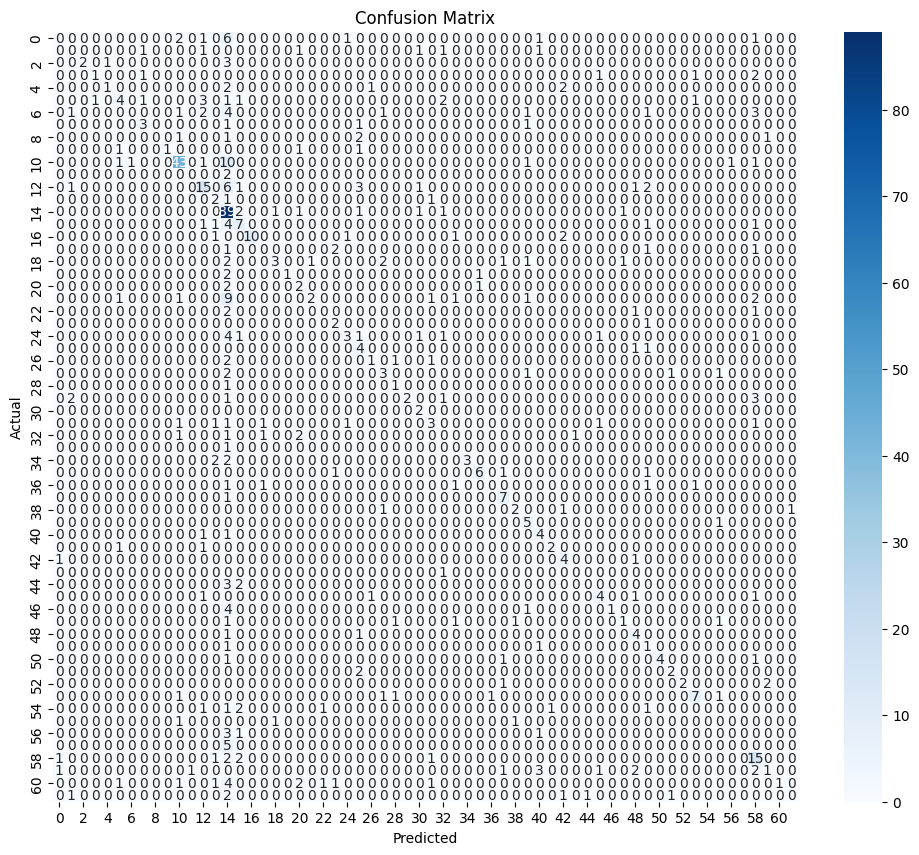

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(12,10))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [24]:
from sklearn.metrics import classification_report

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=lfw.target_names
))

                           precision    recall  f1-score   support

         Alejandro Toledo       0.00      0.00      0.00        12
             Alvaro Uribe       0.00      0.00      0.00         6
          Amelie Mauresmo       1.00      0.33      0.50         6
             Andre Agassi       0.50      0.17      0.25         6
           Angelina Jolie       0.50      0.17      0.25         6
             Ariel Sharon       0.44      0.29      0.35        14
    Arnold Schwarzenegger       0.00      0.00      0.00        14
     Atal Bihari Vajpayee       0.50      0.50      0.50         6
             Bill Clinton       0.00      0.00      0.00         5
             Carlos Menem       1.00      0.25      0.40         4
             Colin Powell       0.81      0.73      0.77        59
            David Beckham       0.00      0.00      0.00         2
          Donald Rumsfeld       0.54      0.50      0.52        30
         George Robertson       0.22      0.50      0.31     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


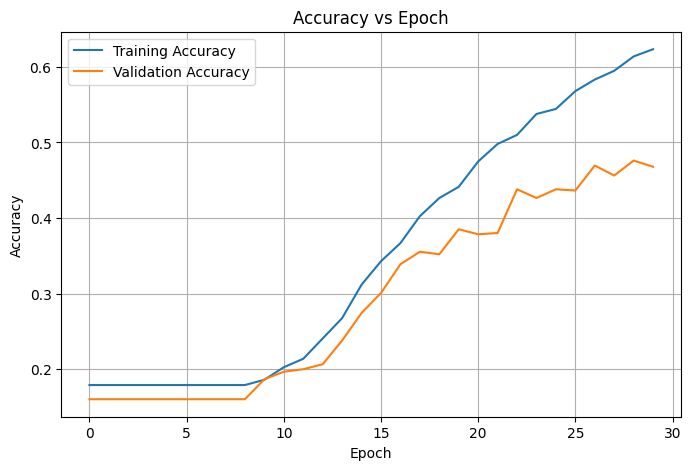

In [25]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Accuracy vs Epoch")

plt.legend()

plt.grid(True)

plt.show()

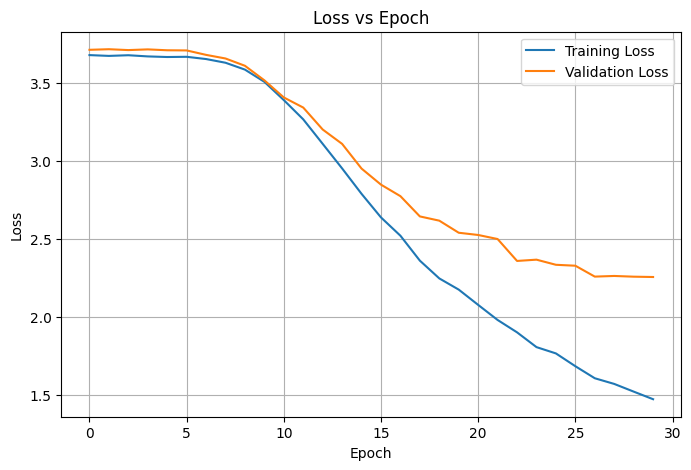

In [26]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss vs Epoch")

plt.legend()

plt.grid(True)

plt.show()

# Observations

1. The CNN model successfully learned facial features from the LFW dataset and achieved good classification performance.

2. The training and validation accuracy improved over the training epochs, indicating that the model learned meaningful facial representations.

3. The confusion matrix shows that most faces were classified correctly, while some misclassifications occurred due to similarities among individuals.

4. CNN automatically extracts important facial features, making it highly effective for face recognition tasks.



## Conclusion

The Face Recognition using CNN project successfully developed a Convolutional Neural Network (CNN) to recognize individuals from the Labeled Faces in the Wild (LFW) dataset. The images were preprocessed by normalizing pixel values, encoding class labels, and splitting the dataset into training and testing sets. The CNN model effectively learned facial features through convolutional and pooling layers, resulting in good recognition performance. The evaluation metrics, confusion matrix, and accuracy graphs demonstrated that the model was able to classify many faces correctly while maintaining satisfactory generalization on unseen data. This project highlights the effectiveness of deep learning techniques in face recognition and demonstrates the practical application of CNNs in computer vision tasks such as identity verification, surveillance, and biometric authentication.

## Key Findings

- The CNN model successfully learned facial features from the LFW dataset.
- Image normalization and proper preprocessing improved the overall recognition performance.
- The model achieved good classification accuracy and demonstrated the effectiveness of CNNs for face recognition tasks.

## Importance of CNN in Face Recognition

- CNN automatically extracts important facial features such as edges, textures, and facial patterns, making it highly effective for recognizing and distinguishing different individuals.

## One Advantage of Deep Learning

- Deep Learning automatically learns complex and meaningful features from images without requiring manual feature extraction.

## One Limitation of CNN

- CNN models require large labeled datasets and significant computational resources for effective training.